# Assignment 3 - Creating Visualization  

Step 1 : Import Libraries and Data

In [25]:
# Step 1: Import libraries
import pandas as pd
import matplotlib.pyplot as plt

# Step 2: Load the CSV (must be in the same folder as this notebook)
df = pd.read_csv("Licensed_Dogs_and_Cats.csv")

# Step 3: Inspect data
print("First 5 rows of the dataset:")
print(df.head())

print("\nColumns in the dataset:")
print(df.columns)

# Step 4: Clean the data
# Strip spaces and make consistent case
df['ANIMAL_TYPE'] = df['ANIMAL_TYPE'].str.strip().str.title()  # 'dog' -> 'Dog', ' CAT ' -> 'Cat'
df['PRIMARY_BREED'] = df['PRIMARY_BREED'].str.strip()

print("\nUnique animal types after cleaning:")
print(df['ANIMAL_TYPE'].unique())


First 5 rows of the dataset:
   _id  Year  FSA ANIMAL_TYPE  PRIMARY_BREED
0    1  2023  M3A         DOG  CAVALIER SPAN
1    2  2023  M1K         CAT    DOMESTIC MH
2    3  2023  M4C         CAT    DOMESTIC SH
3    4  2025  M4B         CAT    DOMESTIC SH
4    5  2023  M1V         CAT    DOMESTIC SH

Columns in the dataset:
Index(['_id', 'Year', 'FSA', 'ANIMAL_TYPE', 'PRIMARY_BREED'], dtype='object')

Unique animal types after cleaning:
['Dog' 'Cat']


# Visualization 1: Annual Trend of Dogs vs Cats

<Figure size 1000x600 with 0 Axes>

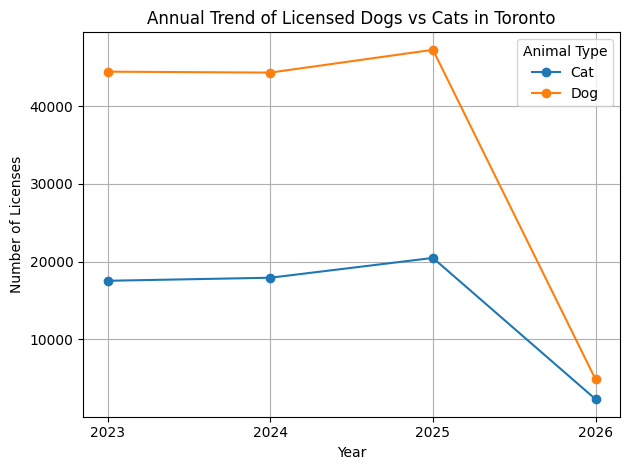

<Figure size 640x480 with 0 Axes>

In [26]:
# Group data by Year and ANIMAL_TYPE
annual_counts = df.groupby(['Year', 'ANIMAL_TYPE']).size().unstack(fill_value=0)

# Plot
plt.figure(figsize=(10,6))
annual_counts.plot(kind='line', marker='o')
plt.title("Annual Trend of Licensed Dogs vs Cats in Toronto")
plt.xlabel("Year")
plt.ylabel("Number of Licenses")
plt.xticks(annual_counts.index)  # Show all years
plt.grid(True)
plt.legend(title="Animal Type")
plt.tight_layout()
plt.show()

# save this visualization 
plt.savefig("Annual Trend of Licensed Dogs vs Cats in Toronto.png", dpi=300)  # high resolution

# Visualization 2: Top 10 Breeds for Dogs and Cats

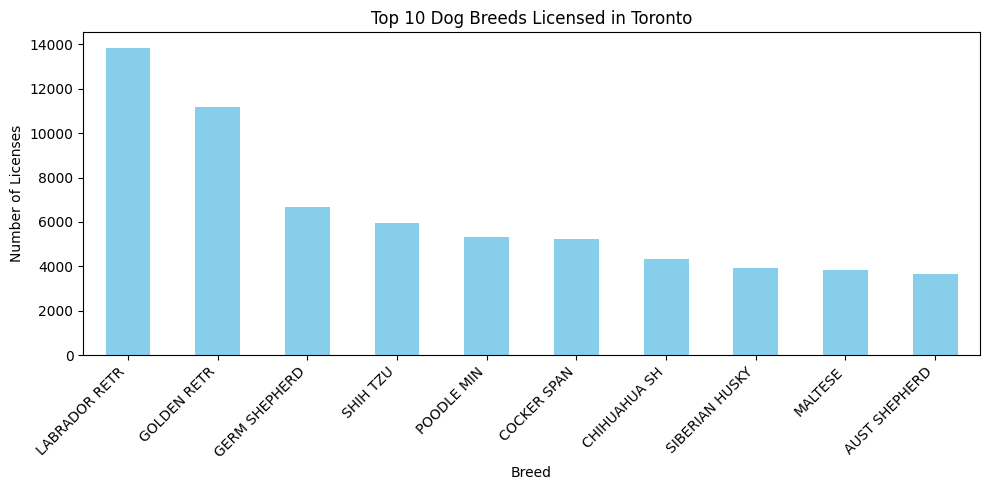

In [27]:
# Filter top 10 dog breeds
top_dog_breeds = df[df['ANIMAL_TYPE']=='Dog']['PRIMARY_BREED'].value_counts().head(10)
# Filter top 10 cat breeds
top_cat_breeds = df[df['ANIMAL_TYPE']=='Cat']['PRIMARY_BREED'].value_counts().head(10)

# Check if the series is empty before plotting
if not top_dog_breeds.empty:
    plt.figure(figsize=(10,5))
    top_dog_breeds.plot(kind='bar', color='skyblue')
    plt.title("Top 10 Dog Breeds Licensed in Toronto")
    plt.xlabel("Breed")
    plt.ylabel("Number of Licenses")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No Dog data available to plot.")


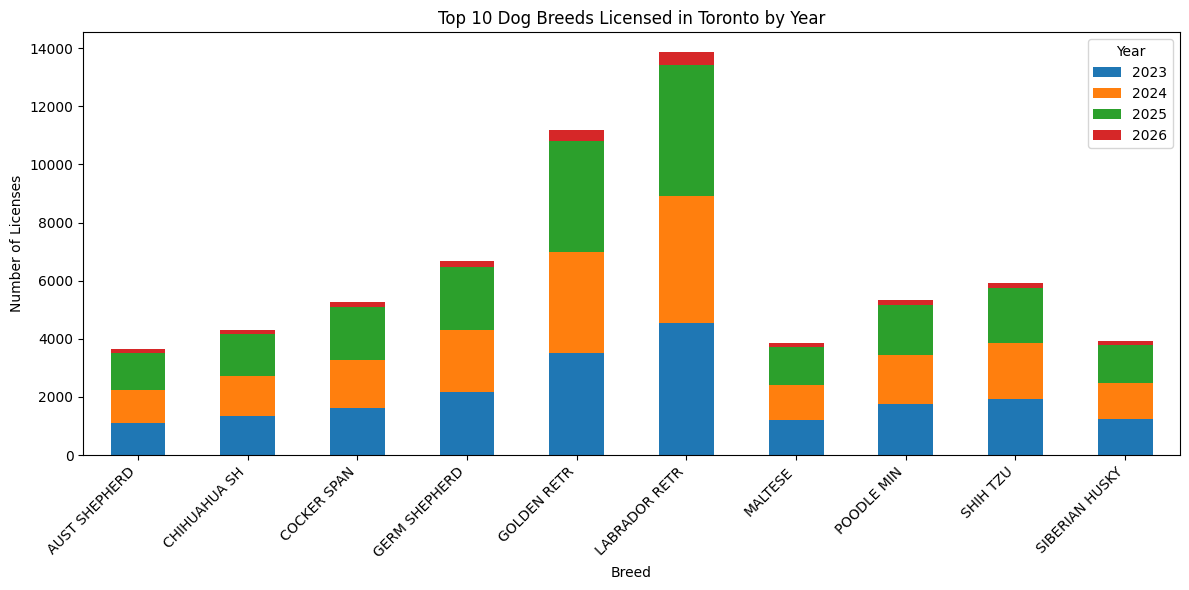

<Figure size 640x480 with 0 Axes>

In [28]:
# Step 1: Filter top 10 dog breeds overall
top_dog_breeds_names = df[df['ANIMAL_TYPE']=='Dog']['PRIMARY_BREED'].value_counts().head(10).index

# Step 2: Filter dataframe to only include top 10 breeds
top_dog_df = df[(df['ANIMAL_TYPE']=='Dog') & (df['PRIMARY_BREED'].isin(top_dog_breeds_names))]

# Step 3: Pivot table: rows = breed, columns = year, values = count
dog_pivot = top_dog_df.pivot_table(index='PRIMARY_BREED', columns='Year', aggfunc='size', fill_value=0)

# Step 4: Plot stacked bar chart
dog_pivot.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title("Top 10 Dog Breeds Licensed in Toronto by Year")
plt.xlabel("Breed")
plt.ylabel("Number of Licenses")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Year")
plt.tight_layout()
plt.show()


# save this visualization 
plt.savefig("Top_10_Dog_Breeds_by_Year.png", dpi=300)  # high resolution
